# Global pressure-based models: Extended data figures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import polars as pl
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from pathlib import Path
import json
import importlib
import ast
import jupyter_black

jupyter_black.load()

## Visual settings across all plots

In [2]:
# Set global Seaborn theme
sns.set_theme(
    style="white",  # White background
    context="notebook",  # Default context; adjust font sizes for notebooks
    rc={
        "axes.spines.top": False,  # Remove top spine
        "axes.spines.right": False,  # Remove right spine
        "axes.grid": False,  # Disable gridlines
        "xtick.bottom": True,  # Enable bottom ticks
        "ytick.left": True,  # Enable left ticks
        "xtick.major.size": 6,  # Length of major x-axis ticks
        "ytick.major.size": 6,  # Length of major y-axis ticks
        "axes.titlesize": 14,  # Font size for titles
        "axes.labelsize": 11,  # Font size for axis labels
        "legend.fontsize": 11,  # Font size for legends
    },
)

color_scheme = {  # https://matplotlib.org/stable/gallery/color/named_colors.html
    "calibration": "teal",
    "fixed_eff": "lightsteelblue",
    "random_eff": "peachpuff",
    "training": "darkgray",
    "standard_cv": "darkseagreen",
    "cross_study_cv": "mediumseagreen",
    "train_line": "royalblue",
    "test_line": "orange",
    "group_scatter": "darkolivegreen",
}

summary_colors = {
    "Training": color_scheme["training"],
    "Standard CV": color_scheme["standard_cv"],
    "Cross-study CV": color_scheme["cross_study_cv"],
}

## Source folder paths for base model runs

In [3]:
# ALPHA diversity: Base model runs

lmm_alpha_folders = {
    "Training": "lmm_alpha_train",
    "Standard CV": "lmm_alpha_standard_cv",
    "Cross-study CV": "lmm_alpha_cross_study",
}

bhm_alpha_folders = {
    "Training": "bhm_alpha_train_sqrt",
    "Standard CV": "bhm_alpha_standard_cv_sqrt",
    "Cross-study CV": "bhm_alpha_cross_study_sqrt",
}

# BETA diversity: Base model runs

lmm_beta_folders = {
    "Training": "lmm_beta_train",
    "Standard CV": "lmm_beta_standard_cv",
    "Cross-study CV": "lmm_beta_cross_study",
}

bhm_beta_folders = {
    "Training": "bhm_beta_train_log",
    "Standard CV": "bhm_beta_standard_cv_log",
    "Cross-study CV": "bhm_beta_cross_study_log",
}

# Base paths and file endings
base_path = "../../data/saved_runs"
key_output_path = "key_output"
site_info_filename = "site_info.parquet"
bhm_added_output_path = "additional_output"

In [4]:
# Get functions from the main figure notebook
NB_NAME = "1_manuscript_main.ipynb"
MODULE_NAME = "1_manuscript_module.py"

# Index numbers of the global config/import cells
GLOBAL_CELL_INDICES = {1, 3, 5}


def extract_globals_and_functions(nb_path, module_path):
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    global_blocks = []
    function_blocks = []

    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue

        src = "".join(cell["source"])

        # 1) Exact cell index match
        if i in GLOBAL_CELL_INDICES:
            global_blocks.append(src)
            continue

        # 2) Extract only function/class definitions
        try:
            tree = ast.parse(src)
        except SyntaxError:
            continue

        keep = []
        for node in tree.body:
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                keep.append(node)

        if keep:
            mod = ast.Module(body=keep, type_ignores=[])
            function_blocks.append(ast.unparse(mod))

    final_code = "\n\n".join(global_blocks + function_blocks)

    with open(module_path, "w", encoding="utf-8") as f:
        f.write(final_code)

    print(
        f"Exported {module_path} with {len(global_blocks)} globals and {len(function_blocks)} function blocks."
    )


# --- Export and import ---
extract_globals_and_functions(NB_NAME, MODULE_NAME)

# --- Import the freshly updated module ---
main_figs = importlib.import_module(Path(MODULE_NAME).stem)
importlib.reload(main_figs)

Exported 1_manuscript_module.py with 3 globals and 30 function blocks.


<module '1_manuscript_module' from '/Users/jakny386/Documents/1_Projects/1_Biodiversity_impacts/biodiversity-impacts/notebooks/1_manuscript_module.py'>

## Extract data from training and cross-validation runs

In [5]:
# Produce dicts of model and mode dataframes from data path dict
lmm_alpha_results = main_figs.load_prediction_dataframes(lmm_alpha_folders)
bhm_alpha_results = main_figs.load_prediction_dataframes(bhm_alpha_folders)
lmm_beta_results = main_figs.load_prediction_dataframes(lmm_beta_folders)
bhm_beta_results = main_figs.load_prediction_dataframes(bhm_beta_folders)

In [14]:
lmm_alpha_results

{'Training': shape: (25_987, 6)
 ┌──────────────────────────┬──────────────┬──────────────┬───────────────────┬──────────┬──────────┐
 │ SSBS                     ┆ Predicted_RE ┆ Predicted_FE ┆ Reference_pred_FE ┆ Observed ┆ mode     │
 │ ---                      ┆ ---          ┆ ---          ┆ ---               ┆ ---      ┆ ---      │
 │ str                      ┆ f64          ┆ f64          ┆ f64               ┆ f64      ┆ str      │
 ╞══════════════════════════╪══════════════╪══════════════╪═══════════════════╪══════════╪══════════╡
 │ DI1_2010__Milder 2  17   ┆ 0.536643     ┆ 0.598228     ┆ 0.607552          ┆ 0.347484 ┆ Training │
 │ SS1_2011__Mulder 4 B445  ┆ 0.567823     ┆ 0.394502     ┆ 0.607552          ┆ 0.50805  ┆ Training │
 │ 189                      ┆              ┆              ┆                   ┆          ┆          │
 │ DI1_2013__Faruk 1 4 8    ┆ 0.663442     ┆ 0.480315     ┆ 0.607552          ┆ 0.712755 ┆ Training │
 │ SH1_2010__Medina 1  82   ┆ 0.056359     ┆ 0.432

# ED Fig 1: PREDICTS data overview

In [6]:
# Load a cross-validation dataframe and site info
df_pred = bhm_alpha_results["Standard CV"]
df_site_info = main_figs.read_site_info_parquet(bhm_alpha_folders["Standard CV"])
df_joined = df_pred.join(df_site_info, on="SSBS", how="left")

In [7]:
def _number_formatter(max_val):
    """Return a formatter function based on the maximum value in the data."""

    def formatter(value, *args):
        if max_val <= 10:
            return f"{value:.1f}"
        else:
            return f"{value:,.0f}"

    return formatter


def plot_frequencies(
    df: pl.DataFrame,
    group_col: str,
    count_type: str,
    secondary_count_type: str | None = None,
    sort_descending: bool = True,
    figsize: tuple = (10, 6),
    color: str = "steelblue",
    alpha: float = 0.8,
    axes_numbers_size: int = 12,
    axes_label_size: int = 12,
    bar_numbers_size: int = 12,
    show_values: bool = True,
    show_axes_labels: bool = True,
    show_axes_numbers: bool = True,
) -> plt.Figure:
    # Helper: map count_type to polars expression
    def get_agg_expr(metric: str):
        if metric == "samples":
            return pl.col("SSBS").count().alias(metric)
        elif metric == "sites":
            return pl.col("SSBS").n_unique().alias(metric)
        elif metric == "studies":
            return pl.col("SS").n_unique().alias(metric)
        else:
            raise ValueError(
                "count_type must be one of ['samples', 'sites', 'studies']"
            )

    # Build aggregation expressions
    agg_exprs = [get_agg_expr(count_type)]
    if secondary_count_type is not None:
        agg_exprs.append(get_agg_expr(secondary_count_type))

    # Group, aggregate, and sort
    df_counts = (
        df.group_by(group_col)
        .agg(agg_exprs)
        .sort(pl.col(count_type), descending=sort_descending)
    )

    # Convert to pandas for seaborn
    df_counts_pd = df_counts.to_pandas()

    # Get max for formatting
    max_val = df_counts_pd[count_type].max()
    formatter = _number_formatter(max_val)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)

    # Horizontal barplot
    sns.barplot(
        data=df_counts_pd,
        x=count_type,
        y=group_col,
        color=color,
        alpha=alpha,
        linewidth=0,
        ax=ax,
    )

    # Axis labels
    if show_axes_labels:
        ax.set_xlabel("Frequency", fontsize=axes_label_size)
        ax.set_ylabel(group_col, fontsize=axes_label_size)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Tick formatting
    if show_axes_numbers:
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
        ax.tick_params(axis="x", labelsize=axes_numbers_size)
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis="y", labelsize=axes_numbers_size)

    # Add bar labels
    if show_values:
        labels = []
        for bar in ax.patches:
            val = bar.get_width()
            text = formatter(val)
            if secondary_count_type is not None:
                # match group from bar y-coordinate
                group = bar.get_y() + bar.get_height() / 2
                # find the nearest category label from y-ticks
                ytick_labels = [t.get_text() for t in ax.get_yticklabels()]
                ytick_pos = [t.get_position()[1] for t in ax.get_yticklabels()]
                # map position → label
                closest = min(
                    range(len(ytick_pos)), key=lambda i: abs(ytick_pos[i] - group)
                )
                group_label = ytick_labels[closest]
                # lookup secondary value from df_counts_pd
                sec_val = df_counts_pd.loc[
                    df_counts_pd[group_col] == group_label, secondary_count_type
                ].iloc[0]
                text = f"{text} ({sec_val})"
            labels.append(text)

        ax.bar_label(
            ax.containers[0],
            labels=labels,
            padding=3,
            fontsize=bar_numbers_size,
        )

    plt.tight_layout()
    return fig

## ED Fig 1a) Biomes 

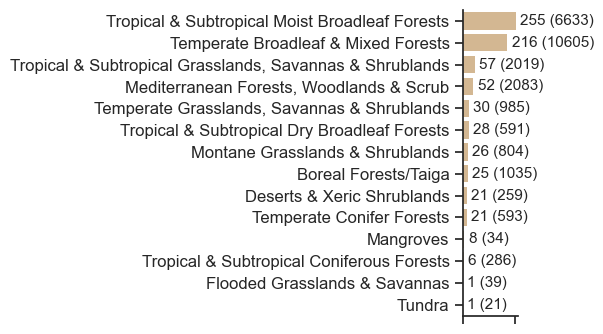

In [8]:
fig = plot_frequencies(
    df_joined,
    group_col="Biome",
    count_type="studies",
    secondary_count_type="sites",
    sort_descending=True,
    figsize=(6, 3.5),
    color="burlywood",
    alpha=1,
    axes_numbers_size=12,
    axes_label_size=10,
    bar_numbers_size=11,
    show_values=True,
    show_axes_labels=False,
    show_axes_numbers=False,
)

In [ ]:
fig.savefig(
    "../../documents/plots/biomes.svg",
    format="svg",
    transparent=True,
)

## ED Fig 1b) Realms

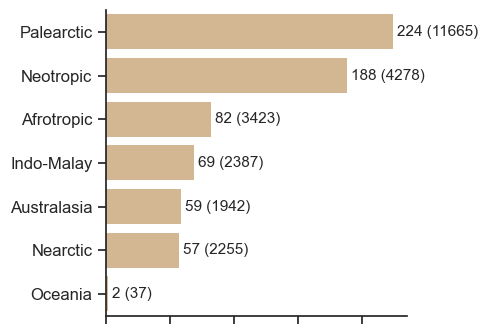

In [9]:
fig = plot_frequencies(
    df_joined,
    group_col="Realm",
    count_type="studies",
    secondary_count_type="sites",
    sort_descending=True,
    figsize=(5, 3.5),
    color="burlywood",
    alpha=1,
    axes_numbers_size=12,
    axes_label_size=10,
    bar_numbers_size=11,
    show_values=True,
    show_axes_labels=False,
    show_axes_numbers=False,
)

fig.savefig(
    "../../documents/plots/realms.svg",
    format="svg",
    transparent=True,
)

## ED Fig 1c) Taxonomic groups (classes)

In [10]:
# Load PREDICTS data
df_predicts = pl.read_csv("../../data/PREDICTS/merged_data.csv")

# Filter the data to match the sites from the training data
sites_in_scope = df_joined.get_column("SSBS").unique().to_list()
df_predicts = df_predicts.filter(pl.col("SSBS").is_in(sites_in_scope))
df_predicts = df_predicts.filter(pl.col("Class") != "Not assigned")

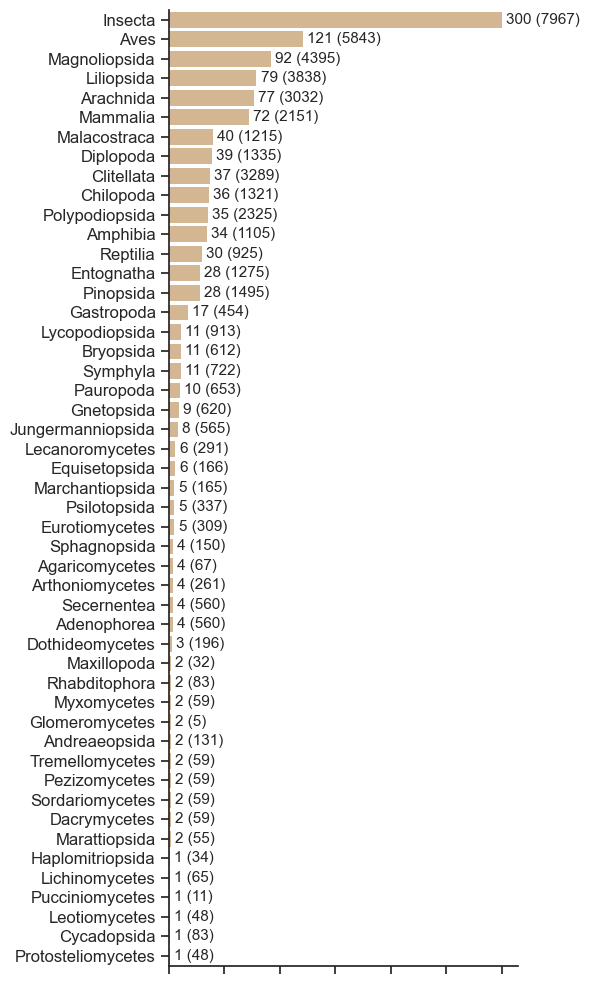

In [11]:
fig = plot_frequencies(
    df_predicts,
    group_col="Class",
    count_type="studies",
    secondary_count_type="sites",
    sort_descending=True,
    figsize=(6, 10),
    color="burlywood",
    alpha=1,
    axes_numbers_size=12,
    axes_label_size=10,
    bar_numbers_size=11,
    show_values=True,
    show_axes_labels=False,
    show_axes_numbers=False,
)

In [ ]:

fig.savefig(
    "../../documents/plots/taxonomic_groups.svg",
    format="svg",
    transparent=True,
)

# ED Fig 1: Number of studies and sites per country

In [ ]:
# Calculate country-level stats on number of studies and sites
# BHM alpha standard CV
bhm_alpha_country_acc_std_cv = main_figs.calculate_country_stats(
    df_pred=bhm_alpha_results["Standard CV"],
    run_folder=bhm_alpha_folders["Standard CV"],
    pred_col="Predicted",
    clip=(0, 1),
)

# Get the best and worst accuracies across alpha and beta for consistent plots
vals = pl.concat(
    [
        bhm_alpha_country_acc_std_cv["Nb_of_studies"],
        bhm_alpha_country_acc_std_cv["Nb_of_sites"],
    ],
    how="vertical",
).to_numpy()

## 2d) Number of studies per country

In [ ]:
fig = plot_world_heatmap(
    bhm_alpha_country_acc_std_cv,
    value_col="Average_r",
    min_max=(vmin, vmax),
    figsize=(6, 4.5),
    cmap=cmap,
    show_legend=False,
    legend_label="Average Pearson r",
    legend_decimals=True,
)

## 2b) Number of sites per country

# ED Fig 2: Response variable data distributions

In [ ]:
# Get data from training runs

# GLMM
df_lmm_alpha_train = lmm_alpha_results["Training"]
df_lmm_beta_train = lmm_beta_results["Training"]

# BHM
df_bhm_alpha_train = bhm_alpha_results["Training"]
df_bhm_beta_train = bhm_beta_results["Training"]

## 2a) Alpha diversity, GMA (GLMM model, site level)

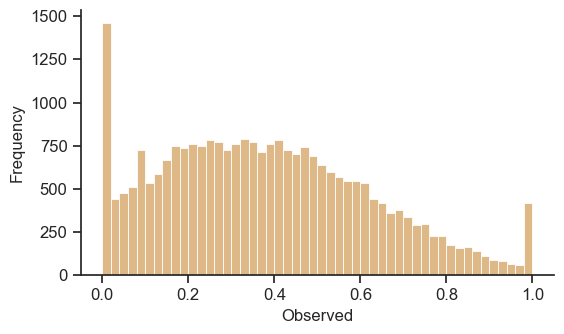

In [33]:
fig = main_figs.plot_histogram(
    df_lmm_alpha_train,
    data_col="Observed",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=True,
    show_axes_numbers=True,
)

In [23]:
fig.savefig(
    "../../documents/plots/lmm_gma_distribution.svg",
    format="svg",
    transparent=True,
)

## 2b) Beta diversity, BC similarity (GLMM model, site level)

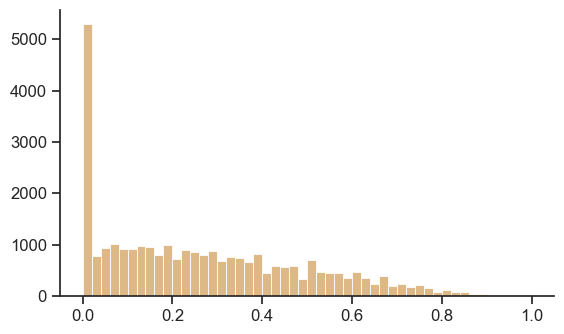

In [34]:
fig = main_figs.plot_histogram(
    df_lmm_beta_train,
    data_col="Observed",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=True,
)

In [25]:
fig.savefig(
    "../../documents/plots/lmm_bc_distribution.svg",
    format="svg",
    transparent=True,
)

## 2c) Alpha diversity, GMA (BHM model, site-taxa level)

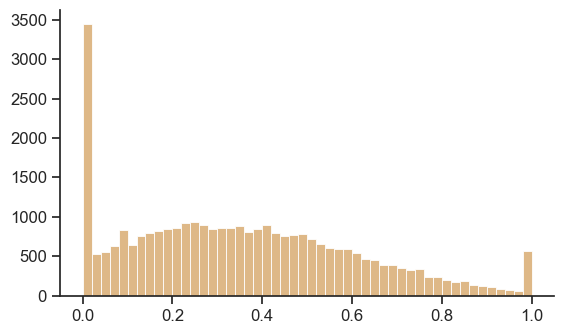

In [35]:
fig = main_figs.plot_histogram(
    df_bhm_alpha_train,
    data_col="Observed",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=True,
)

In [28]:
fig.savefig(
    "../../documents/plots/bhm_gma_distribution.svg",
    format="svg",
    transparent=True,
)

## 2d) Beta diversity, BC similarity (BHM model, site-taxa level)

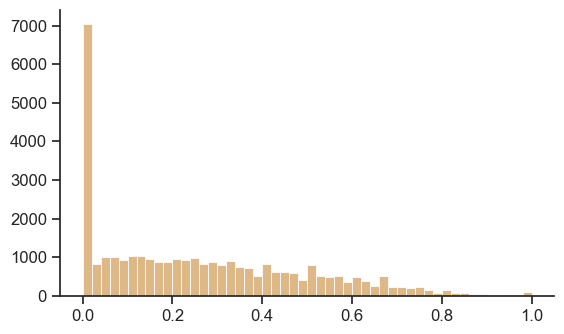

In [36]:
fig = main_figs.plot_histogram(
    df_bhm_beta_train,
    data_col="Observed",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=True,
)

In [31]:
fig.savefig(
    "../../documents/plots/bhm_bc_distribution.svg",
    format="svg",
    transparent=True,
)

# ED Fig 3: Hierarchical group overview

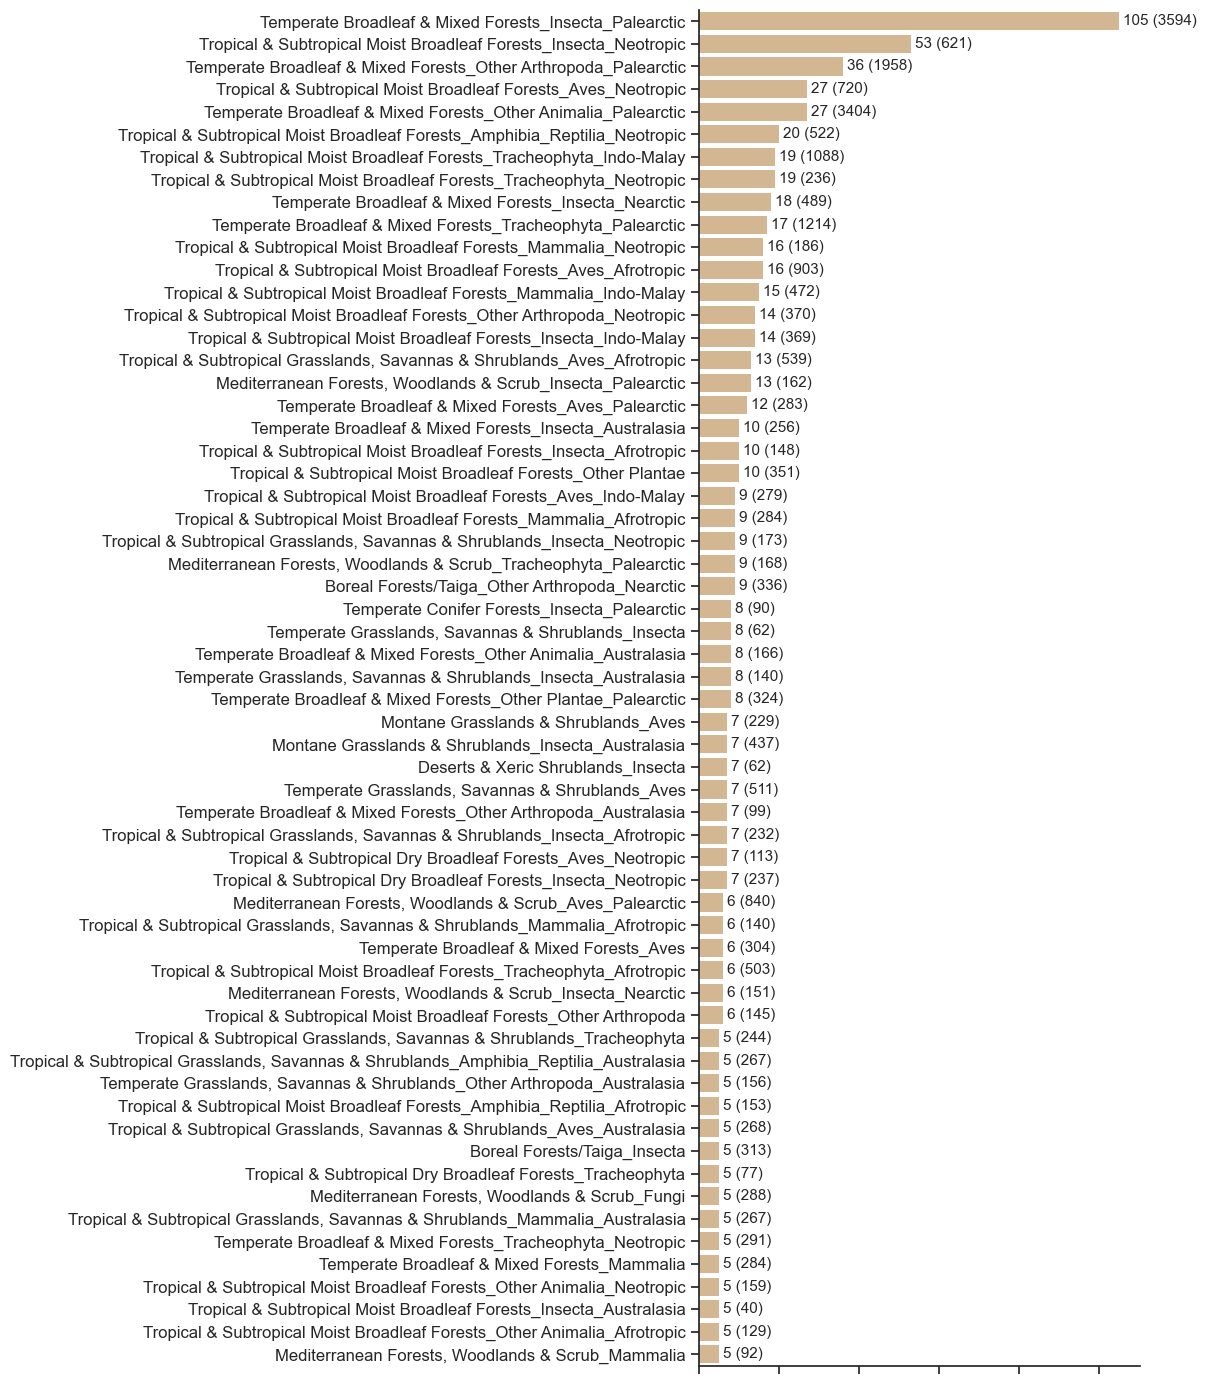

In [ ]:
# Filter out rolled up groups
df_hierarchy = df_joined.filter(pl.col("Final_hierarchical_group") != "Population")

fig = plot_frequencies(
    df_hierarchy,
    group_col="Final_hierarchical_group",
    count_type="studies",
    secondary_count_type="sites",
    sort_descending=True,
    figsize=(12, 14),
    color="burlywood",
    alpha=1,
    axes_numbers_size=12,
    axes_label_size=10,
    bar_numbers_size=11,
    show_values=True,
    show_axes_labels=False,
    show_axes_numbers=False,
)

fig.savefig(
    "../../documents/plots/hierarchical_groups.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

# ED Fig 4: Number of sampling sites per study

In [ ]:
sites_per_study = pl.DataFrame(
    (df_abundance.group_by("SS").agg(pl.col("SSBS").n_unique()).get_column("SSBS"))
)

fig = plot_histogram(
    sites_per_study,
    data_col="SSBS",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=True,
)

fig.savefig(
    "../../plots/manuscript/sites_per_study.svg",
    format="svg",
    transparent=True,
)

In [ ]:
sites_per_study_filter = sites_per_study.filter(pl.col("SSBS") <= 200)

fig = plot_histogram(
    sites_per_study_filter,
    data_col="SSBS",
    bins=50,
    alpha=1,
    color="burlywood",
    figsize=(5.8, 3.5),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=True,
)

fig.savefig(
    "../../plots/manuscript/sites_per_study_200.svg",
    format="svg",
    transparent=True,
)

In [ ]:
# Share with 5 or less
sites_per_study.filter(pl.col("SSBS") <= 5).height / sites_per_study.height

In [ ]:
# Share with 5 or less
sites_per_study.filter(pl.col("SSBS") <= 25).height / sites_per_study.height

In [ ]:
# ALPHA diversity: Base model runs

lmm_alpha_folders = {
    "Training": "lmm_alpha_train",
    "Standard CV": "lmm_alpha_standard_cv",
    "Cross-study CV": "lmm_alpha_cross_study",
}

bhm_alpha_folders = {
    "Training": "bhm_alpha_train_sqrt",
    "Standard CV": "bhm_alpha_standard_cv_sqrt",
    "Cross-study CV": "bhm_alpha_cross_study_sqrt",
}

# BETA diversity: Base model runs

lmm_beta_folders = {
    "Training": "lmm_beta_train",
    "Standard CV": "lmm_beta_standard_cv",
    "Cross-study CV": "lmm_beta_cross_study",
}

bhm_beta_folders = {
    "Training": "bhm_beta_train_log",
    "Standard CV": "bhm_beta_standard_cv_log",
    "Cross-study CV": "bhm_beta_cross_study_log",
}

# Base paths and file endings
base_path = "../../data/saved_runs"
key_output_path = "key_output"
site_info_filename = "site_info.parquet"
bhm_added_output_path = "additional_output"

## GLMM runs with threshold of >= 25 sites

In [ ]:
lmm_alpha_folders_25 = {
    "Training": "lmm_alpha_train_25",
    "Standard CV": "lmm_alpha_standard_cv_25",
    "Cross-study CV": "lmm_alpha_cross_study_25",
}

lmm_beta_folders_25 = {
    "Training": "lmm_beta_train_25",
    "Standard CV": "lmm_beta_standard_cv_25",
    "Cross-study CV": "lmm_beta_cross_study_25",
}

In [ ]:
lmm_alpha_results_25 = load_prediction_dataframes(lmm_alpha_folders_25)
lmm_beta_results_25 = load_prediction_dataframes(lmm_beta_folders_25)

In [ ]:
lmm_25_summary_results = build_model_performance_summary(
    dfs={
        "LMM alpha 25 sites": lmm_alpha_results_25,
        "LMM beta 25 sites": lmm_beta_results_25,
    }
)
lmm_25_summary_results

Model,Eval type,Mean,Min,Max,r_fold_1,r_fold_2,r_fold_3,r_fold_4,r_fold_5
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""LMM alpha 25 sites""","""Training""",0.756067,NaN,NaN,null,null,null,null,null
"""LMM alpha 25 sites""","""Standard CV""",0.136211,0.133547,0.143609,0.135424,0.134023,0.143609,0.139082,0.133547
"""LMM alpha 25 sites""","""Cross-study CV""",0.08712,-0.007388,0.164778,0.164778,0.058375,0.11884,-0.007388,0.092552
"""LMM beta 25 sites""","""Training""",0.807445,NaN,NaN,null,null,null,null,null
"""LMM beta 25 sites""","""Standard CV""",0.187185,0.152871,0.258447,0.258447,0.186274,0.210768,0.152871,0.173074
"""LMM beta 25 sites""","""Cross-study CV""",0.145668,0.037633,0.355475,0.355475,0.037633,0.182233,0.221774,0.107522


# --- ARCHIVE ---

# Figure 4: Normalized intactness estimates

In [ ]:
def calculate_final_outputs(
    df_pred: pl.DataFrame,
    df_site_info: pl.DataFrame,
    min_n: int = 5,
) -> pl.DataFrame:
    # 1. Find eligible studies with enough reference sites
    ref_sites = df_site_info.filter(
        (pl.col("Predominant_land_use") == "Primary vegetation")
        & (pl.col("Use_intensity") == "Minimal use")
    )
    ref_counts = (
        ref_sites.group_by("SS")
        .agg(pl.len().alias("n_sites"))
        .filter(pl.col("n_sites") >= min_n)
    )
    eligible_studies = ref_counts.get_column("SS").to_list()

    # 2. Join SS and land use info onto df_pred
    df_pred = df_pred.join(
        df_site_info.select(["SSBS", "SS", "Predominant_land_use", "Use_intensity"]),
        on="SSBS",
        how="left",
    )

    # 3. Filter df_pred to eligible studies only
    df_pred = df_pred.filter(pl.col("SS").is_in(eligible_studies))

    # 4. Compute reference means (Observed mean among reference sites per study)
    ref_obs = (
        df_pred.filter(
            (pl.col("Predominant_land_use") == "Primary vegetation")
            & (pl.col("Use_intensity") == "Minimal use")
        )
        .group_by("SS")
        .agg(pl.col("Observed").mean().alias("Observed_ref_mean"))
    )

    # 5. Join reference mean to all rows
    df_pred = df_pred.join(ref_obs, on="SS", how="left")

    # Optional: In case of LMM output
    if "Predicted_FE" in df_pred.columns:
        df_pred = df_pred.rename(
            {"Predicted_FE": "Predicted", "Reference_pred_FE": "Reference_pred"}
        )

    # 6. Compute scaled outputs
    df_pred = df_pred.with_columns(
        [
            # Predicted_scaled with clip
            pl.when((pl.col("Predicted") == 0) | (pl.col("Reference_pred") == 0))
            .then(0.0)
            .otherwise((pl.col("Predicted") / pl.col("Reference_pred")).clip(0, 3))
            .alias("Predicted_scaled"),
            # Observed_scaled with clip
            pl.when((pl.col("Observed") == 0) | (pl.col("Observed_ref_mean") == 0))
            .then(0.0)
            .otherwise((pl.col("Observed") / pl.col("Observed_ref_mean")).clip(0, 3))
            .alias("Observed_scaled"),
            # Predicted_scaled_capped at 1.0 regardless of clip arg
            pl.when((pl.col("Predicted") == 0) | (pl.col("Reference_pred") == 0))
            .then(0.0)
            .otherwise((pl.col("Predicted") / pl.col("Reference_pred")).clip(0, 1.0))
            .alias("Predicted_scaled_capped"),
        ]
    )

    # Drop any rows with NaN or infinite values in critical columns
    df_pred = df_pred.filter(
        ~(
            pl.any_horizontal(
                [
                    pl.col("Predicted_scaled").is_nan()
                    | pl.col("Predicted_scaled").is_infinite(),
                    pl.col("Observed_scaled").is_nan()
                    | pl.col("Observed_scaled").is_infinite(),
                    pl.col("Predicted_scaled_capped").is_nan()
                    | pl.col("Predicted_scaled_capped").is_infinite(),
                ]
            )
        )
    )

    return df_pred

In [ ]:
def plot_intactness_histogram(
    df: pl.DataFrame,
    col_names: list[str],
    colors: list[str],
    alphas: list[float],
    figsize: tuple,
    show_ax_labels: bool,
    axes_label_size: int,
    axes_tick_size: int,
    bins: int,
    x_label: str,
    y_label: str,
    legend_labels: list[str],
    show_legend: bool,
) -> plt.Figure:
    arrays = [df[col].to_numpy() for col in col_names]
    fig, ax = plt.subplots(figsize=figsize)

    # Determine consistent bins
    global_min = min(np.min(arr) for arr in arrays)
    global_max = max(np.max(arr) for arr in arrays)
    bin_edges = np.linspace(global_min, global_max, bins + 1)

    # Plot main histograms: Observed, Predicted (uncapped)
    for arr, color, alpha, label in zip(arrays[:2], colors, alphas, legend_labels[:2]):
        ax.hist(
            arr,
            bins=bin_edges,
            color=color,
            alpha=alpha,
            label=label,
            edgecolor="white",
            linewidth=0.7,
        )

    # Plot capped-at-1 overlay
    # capped_values = arrays[2]
    # capped_ones = capped_values[capped_values == 1.0]

    # if len(capped_ones) > 0:
    #  ax.hist(
    #     capped_ones,
    #    bins=bin_edges,
    #   color=colors[1],  # same as uncapped prediction
    #   alpha=alphas[1],  # same alpha
    #   hatch="///",
    #   edgecolor="black",  # white hatch color via edge
    #   linewidth=0.5,  # no visible border
    # )

    # Axis labels
    ax.set_xlabel(x_label if show_ax_labels else "", fontsize=axes_label_size)
    ax.set_ylabel("", fontsize=axes_label_size)  # No y label
    ax.tick_params(axis="y", which="both", labelleft=False)  # hide labels
    ax.yaxis.set_major_locator(
        plt.MaxNLocator(nbins=4, prune="both")
    )  # show ~min/max ticks only
    ax.tick_params(axis="x", labelsize=axes_tick_size)

    # Legend
    if show_legend:
        # Add custom hatch patch for the capped values
        hatch_patch = mpatches.Patch(
            facecolor=colors[1],
            alpha=alphas[1],
            edgecolor="black",
            hatch="///",
            label=legend_labels[2],
        )
        handles, labels = ax.get_legend_handles_labels()
        handles.append(hatch_patch)
        labels.append(legend_labels[2])
        ax.legend(
            handles=handles,
            labels=labels,
            fontsize=axes_label_size,
            bbox_to_anchor=(1.02, 1),
            frameon=False,
        )

    plt.tight_layout()
    plt.show()
    return fig

## BHM alpha model

In [ ]:
df_final_bhm_alpha_site = calculate_final_outputs(df_bhm_alpha_site, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_bhm_alpha_site,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/bhm_alpha_intactness_distr_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_bhm_alpha_site.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_bhm_alpha_site.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["bhm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/bhm_alpha_intactness_scatter_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
df_final_bhm_alpha_study = calculate_final_outputs(df_bhm_alpha_study, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_bhm_alpha_study,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/bhm_alpha_intactness_distr_study.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_bhm_alpha_study.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_bhm_alpha_study.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["bhm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/bhm_alpha_intactness_scatter_study.svg",
    format="svg",
    transparent=True,
)

## BHM beta model

In [ ]:
df_final_bhm_beta_site = calculate_final_outputs(df_bhm_beta_site, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_bhm_beta_site,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized similarity",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/bhm_beta_intactness_distr_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_bhm_beta_site.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_bhm_beta_site.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["bhm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized similarity",
    y_label="Est. normalized similarity",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/bhm_beta_intactness_scatter_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
df_final_bhm_beta_study = calculate_final_outputs(df_bhm_beta_study, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_bhm_beta_study,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized similarity",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/bhm_beta_intactness_distr_study.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_bhm_beta_study.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_bhm_beta_study.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["bhm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized similarity",
    y_label="Est. normalized similarity",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/bhm_beta_intactness_scatter_study.svg",
    format="svg",
    transparent=True,
)

# LMM alpha model

In [ ]:
df_final_lmm_alpha_site = calculate_final_outputs(df_lmm_alpha_site, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_lmm_alpha_site,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/lmm_alpha_intactness_distr_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_lmm_alpha_site.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_lmm_alpha_site.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["lmm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/lmm_alpha_intactness_scatter_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
df_final_lmm_alpha_study = calculate_final_outputs(df_lmm_alpha_study, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_lmm_alpha_study,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/lmm_alpha_intactness_distr_study.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_lmm_alpha_study.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_lmm_alpha_study.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["lmm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.3,
)
fig.savefig(
    "../../plots/manuscript/lmm_alpha_intactness_scatter_study.svg",
    format="svg",
    transparent=True,
)

# LMM beta model

In [ ]:
df_final_lmm_beta_site = calculate_final_outputs(df_lmm_beta_site, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_lmm_beta_site,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/lmm_beta_intactness_distr_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_lmm_beta_site.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_lmm_beta_site.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["lmm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.01,
)
fig.savefig(
    "../../plots/manuscript/lmm_beta_intactness_scatter_site.svg",
    format="svg",
    transparent=True,
)

In [ ]:
df_final_lmm_beta_study = calculate_final_outputs(df_lmm_beta_study, df_site_info)

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_lmm_beta_study,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=14,
    axes_tick_size=14,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized & capped at 1",
    ],
    show_legend=False,
)
fig.savefig(
    "../../plots/manuscript/lmm_beta_intactness_distr_study.svg",
    format="svg",
    transparent=True,
)

In [ ]:
fig = plot_calibration_scatter(
    x_array=df_final_lmm_beta_study.get_column("Observed_scaled").to_numpy(),
    y_array=df_final_lmm_beta_study.get_column("Predicted_scaled").to_numpy(),
    figsize=(3.2, 2.8),
    show_ax_labels=True,
    axes_label_size=12,
    axes_tick_size=12,
    color=color_scheme["lmm_alpha"],
    alpha=0.8,
    point_size=10,
    show_metrics=True,
    show_best_fit_line=True,
    x_label="Obs. normalized abundance",
    y_label="Est. normalized abundance",
    xlim=(0, 2),
    ylim=(0, 2),
    sample_frac=0.01,
)
fig.savefig(
    "../../plots/manuscript/lmm_beta_intactness_scatter_study.svg",
    format="svg",
    transparent=True,
)

### Distribution legend

In [ ]:
fig = plot_intactness_histogram(
    df=df_final_lmm_beta_study,
    col_names=["Observed_scaled", "Predicted_scaled", "Predicted_scaled_capped"],
    colors=["#1f77b4", "#ff7f0e"],
    alphas=[0.9, 0.6],
    figsize=(3.2, 3),
    show_ax_labels=True,
    axes_label_size=11,
    axes_tick_size=11,
    bins=30,
    x_label="Normalized abundance",
    y_label="Count of observations",
    legend_labels=[
        "Observed, normalized",
        "Estimated, normalized",
        "Estimated, normalized and capped at 1",
    ],
    show_legend=True,
)
fig.savefig(
    "../../plots/manuscript/intactness_distr_legend.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

# Figure 6: Number of sites per study

# LMM results per species group and biome

In [ ]:
def plot_model_performance_comparison(
    performance_dict,
    figsize,
    title,
    title_size,
    subtitle,
    subtitle_size,
    axes_numbers_size,
    axes_label_size,
    colors,
    alpha,
    vertical_dashed_line,
    show_legend,
    hide_y_axis,
):
    data = []
    for model, eval_types in performance_dict.items():
        for eval_type, value in eval_types.items():
            data.append({"Model": model, "Eval type": eval_type, "Score": value})
    df = pd.DataFrame(data)

    order = ["Training", "Standard CV", "Cross-study CV"]
    df["Eval type"] = pd.Categorical(df["Eval type"], categories=order, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df,
        x="Model",
        y="Score",
        hue="Eval type",
        palette=colors,
        ax=ax,
        dodge=True,
        edgecolor="white",
        alpha=alpha,
        legend=True if show_legend else False,
    )

    for bar in ax.patches:
        height = bar.get_height()
        if height != 0:
            offset = 0.02 if height > 0 else -0.05
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + offset,
                f"{height:.2f}",
                ha="center",
                va="bottom" if height > 0 else "top",
                fontsize=axes_numbers_size,
            )

    # Optional: Vertical dashed line
    if vertical_dashed_line:
        ax.axvline(x=vertical_dashed_line, color="gray", linestyle="--", linewidth=1.0)

    # Format axes labels
    ax.set_ylabel("Pearson's r", fontsize=axes_label_size)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=axes_label_size)
    ax.tick_params(axis="y", labelsize=axes_numbers_size)

    if hide_y_axis:
        ax.yaxis.set_visible(False)
        ax.spines["left"].set_visible(False)

    # Title and subtitle
    fig.text(0.02, 0.95, s=title, fontsize=title_size, ha="left")
    fig.text(0.02, 0.89, s=subtitle, fontsize=subtitle_size, ha="left")

    if show_legend:
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(1, 1),
            frameon=False,
            fontsize=axes_label_size,
            edgecolor="none",
            title="",
        )

    plt.tight_layout(rect=[0, 0, 1, 0.87])
    plt.show()

    return fig

In [ ]:
input_data_folders = {
    ("BII reference \n" "All data \n" "(n=681 studies)"): {
        "Training": "run_folder_2025-05-06_09.55.11",
        "Standard CV": "run_folder_2025-05-06_09.58.13",
        "Cross-study CV": "run_folder_2025-05-06_10.02.37",
    },
    "LMM simplified \n"
    "All data \n"
    "(n=681 studies)": {
        "Training": "run_folder_2025-04-30_14.09.18",
        "Standard CV": "run_folder_2025-04-30_14.11.35",
        "Cross-study CV": "run_folder_2025-04-30_14.14.57",
    },
    ("Tropical & Subtropical \n" "Moist Broadleaf Forests \n" "(n=254 studies)"): {
        "Training": "run_folder_2025-05-08_10.56.24",
        "Standard CV": "run_folder_2025-05-08_11.01.16",
        "Cross-study CV": "run_folder_2025-05-08_11.03.07",
    },
    ("Temperate Broadleaf \n" "& Mixed Forests \n" "(n=216 studies)"): {
        "Training": "run_folder_2025-05-08_11.19.24",
        "Standard CV": "run_folder_2025-05-08_11.17.03",
        "Cross-study CV": "run_folder_2025-05-08_11.09.35",
    },
    (
        "Tropical & Subtropical \n"
        "Grasslands, Savannas \n"
        "& Shrublands \n"
        "(n=57 studies)"
    ): {
        "Training": "run_folder_2025-05-08_11.32.57",
        "Standard CV": "run_folder_2025-05-08_11.35.02",
        "Cross-study CV": "run_folder_2025-05-08_11.35.57",
    },
}

model_performance_dict = calculate_model_metrics(input_data_folders, model_types="lmm")

In [ ]:
fig = plot_model_performance_comparison(
    model_performance_dict,
    figsize=(11, 4),
    title="LMM-based alpha models: Benchmark of model performance",
    title_size=14,
    subtitle="Correlation between predicted and observed values",
    subtitle_size=12,
    axes_label_size=11,
    axes_numbers_size=10,
    colors={
        "Training": color_scheme["train_bar"],
        "Standard CV": color_scheme["site_cv_bar"],
        "Cross-study CV": color_scheme["study_cv_bar"],
    },
    alpha=1,
    vertical_dashed_line=1.5,
)
fig.savefig("../../plots/geobon/lmm_benchmark.svg", format="svg", transparent=True)

# BHM with thresholds on number of sites per study

In [ ]:
input_data_folders = {
    "Min. 10 sites": {
        "Training": "run_folder_2025-05-12_12.43.18",
        "Standard CV": "run_folder_2025-05-09_15.35.08",
        "Cross-study CV": "run_folder_2025-05-09_20.44.52",
    },
    "Min. 25 sites": {
        "Training": "run_folder_2025-05-12_09.39.07",
        "Standard CV": "run_folder_2025-05-10_09.09.16",
        "Cross-study CV": "run_folder_2025-05-10_17.56.13",
    },
    "Min. 50 sites": {
        "Training": "run_folder_2025-05-12_08.47.03",
        "Standard CV": "run_folder_2025-05-10_23.33.00",
        "Cross-study CV": "run_folder_2025-05-11_08.15.30",
    },
}

model_performance_dict = calculate_model_metrics(
    input_data_folders, model_types="mixed"
)

In [ ]:
fig = plot_model_performance_comparison(
    model_performance_dict,
    figsize=(11, 4),
    title="Alpha diversity: Benchmark of model performance",
    title_size=14,
    subtitle="Correlation between predicted and observed values",
    subtitle_size=12,
    axes_label_size=11,
    axes_numbers_size=10,
    colors={
        "Training": color_scheme["train_bar"],
        "Standard CV": color_scheme["site_cv_bar"],
        "Cross-study CV": color_scheme["study_cv_bar"],
    },
    alpha=1,
    vertical_dashed_line=None,
)

# Figure 5: Spatial aggregation of predictions

In [ ]:
def compute_performance_by_resolution(
    df_predictions,
    site_info_path,
    resolutions_km,
    prediction_col,
    observed_col,
    id_col="SSBS",
    lat_col="Latitude",
    lon_col="Longitude",
):
    km_to_deg = 1 / 111.32
    columns_to_add = [id_col, lon_col, lat_col, "SS"]

    # Join predictions with site metadata
    df_joined = df_predictions.join(
        df_site_info.select(columns_to_add), on=id_col, how="left"
    )

    df = df_joined.clone()
    aggregated_dfs = {}
    correlations = {}
    bias_stats = {}
    avg_cell_counts = {}

    # Include raw (non-aggregated) point
    raw_corr = np.corrcoef(df[prediction_col].to_numpy(), df[observed_col].to_numpy())[
        0, 1
    ]
    correlations["raw"] = raw_corr
    avg_cell_counts["raw"] = 1  # 1 per "cell" in raw case

    for res in resolutions_km:
        cell_size = km_to_deg * res
        x_col = f"x_bin_{res}km"
        y_col = f"y_bin_{res}km"
        group_id_col = f"group_id_{res}km"

        # Assign bins
        df = df.with_columns(
            [
                (pl.col(lon_col) / cell_size).floor().cast(pl.Int32).alias(x_col),
                (pl.col(lat_col) / cell_size).floor().cast(pl.Int32).alias(y_col),
                (
                    (pl.col(lat_col) / cell_size).floor().cast(pl.Utf8)
                    + "_"
                    + (pl.col(lon_col) / cell_size).floor().cast(pl.Utf8)
                ).alias(group_id_col),
                (pl.col(prediction_col) - pl.col(observed_col)).alias("Residual"),
            ]
        )

        # Aggregate within spatial bins
        df_agg = (
            df.group_by(group_id_col)
            .agg(
                [
                    pl.col(observed_col).mean().alias("Observed_mean"),
                    pl.col(prediction_col).mean().alias("Predicted_mean"),
                    pl.len().alias("Site_count"),
                    pl.col("SS").n_unique().alias("Study_count"),
                    pl.col(x_col).first().alias("x_bin"),
                    pl.col(y_col).first().alias("y_bin"),
                ]
            )
            .with_columns(
                [
                    (pl.col("x_bin") * cell_size + cell_size / 2).alias(
                        "Longitude_center"
                    ),
                    (pl.col("y_bin") * cell_size + cell_size / 2).alias(
                        "Latitude_center"
                    ),
                ]
            )
        )

        aggregated_dfs[res] = df_agg

        # Pearson correlation
        observed = df_agg["Observed_mean"].to_numpy()
        predicted = df_agg["Predicted_mean"].to_numpy()
        corr = np.corrcoef(observed, predicted)[0, 1] if len(observed) > 1 else np.nan
        correlations[res] = corr

        # Mean entities per cell
        avg_cell_counts[res] = {
            "sites": np.round(df_agg["Site_count"].mean(), 1),
            "studies": np.round(df_agg["Study_count"].mean(), 1),
        }

        # Aggregate and compute bias statistics
        df_bias = (
            df.group_by(group_id_col)
            .agg(
                [
                    pl.col("Residual").mean().alias("Residual_mean"),
                    (pl.col("Residual") > 0).sum().alias("n_overbiased"),
                    (pl.col("Residual") < 0).sum().alias("n_underbiased"),
                    pl.len().alias("Site_count"),
                ]
            )
            .with_columns(
                [
                    (pl.col("n_overbiased") / pl.col("Site_count")).alias(
                        "perc_overbiased"
                    ),
                    (pl.col("n_underbiased") / pl.col("Site_count")).alias(
                        "perc_underbiased"
                    ),
                ]
            )
        )

        bias_stats[res] = df_bias

    return correlations, bias_stats, avg_cell_counts, aggregated_dfs

In [ ]:
def compute_performance_by_resolution(
    df_predictions,
    site_info_path,
    resolutions_km,
    prediction_col,
    observed_col,
    id_col="SSBS",
    lat_col="Latitude",
    lon_col="Longitude",
):
    """
    Aggregates predictions across equal-area grid cells by projecting to local UTM zones.
    """

    projections = Projections()
    columns_to_add = [id_col, lon_col, lat_col, "SS"]

    # Join predictions with site metadata
    # Get unique information (in case of beta diversity run)
    df_site_info = pl.read_parquet(site_info_path)
    df_site_info = df_site_info.unique(subset=[id_col], keep="first")
    df_joined = df_predictions.join(
        df_site_info.select(columns_to_add), on=id_col, how="left"
    )

    df = df_joined.clone()
    aggregated_dfs = {}
    correlations = {}
    bias_stats = {}
    avg_cell_counts = {}

    # Compute raw (non-aggregated) correlation
    raw_corr = np.corrcoef(df[prediction_col].to_numpy(), df[observed_col].to_numpy())[
        0, 1
    ]
    correlations["raw"] = raw_corr
    avg_cell_counts["raw"] = 1

    # Create geometry
    df = df.with_columns(pl.struct([lon_col, lat_col]).alias("coords"))

    # Drop rows with missing coordinates
    height_before = df.height
    df = df.filter(pl.col(lat_col).is_not_null() & pl.col(lon_col).is_not_null())
    height_after = df.height
    n_dropped = height_before - height_after
    if n_dropped > 0:
        print(f"Dropped {n_dropped} sites with missing coordinates.")

    # Convert to GeoDataFrame for spatial operations
    gdf = gpd.GeoDataFrame(
        df.to_pandas(),
        geometry=[Point(xy["Longitude"], xy["Latitude"]) for xy in df["coords"]],
        crs="EPSG:4326",
    )

    for res in resolutions_km:
        cell_size_m = res * 1000
        records = []

        for i, row in gdf.iterrows():
            geom = row.geometry
            utm_geom, epsg_code = projections.project_to_local_utm(geom)

            # Determine cell indices in local UTM space
            x_bin = int(np.floor(utm_geom.x / cell_size_m))
            y_bin = int(np.floor(utm_geom.y / cell_size_m))
            group_id = f"{epsg_code}_{x_bin}_{y_bin}"

            records.append(
                {
                    **row,
                    "x_bin": x_bin,
                    "y_bin": y_bin,
                    "epsg_code": epsg_code,
                    "group_id": group_id,
                    "Residual": row[prediction_col] - row[observed_col],
                }
            )

        df_eq = pl.DataFrame(records)

        # Aggregate within UTM grid cells
        df_agg = df_eq.group_by("group_id").agg(
            [
                pl.col(observed_col).mean().alias("Observed_mean"),
                pl.col(prediction_col).mean().alias("Predicted_mean"),
                pl.len().alias("Site_count"),
                pl.col("SS").n_unique().alias("Study_count"),
                pl.col("x_bin").first(),
                pl.col("y_bin").first(),
                pl.col("epsg_code").first(),
            ]
        )

        # Compute approximate centers (in projected coordinates)
        df_agg = df_agg.with_columns(
            [
                (pl.col("x_bin") * cell_size_m + cell_size_m / 2).alias("x_center_m"),
                (pl.col("y_bin") * cell_size_m + cell_size_m / 2).alias("y_center_m"),
            ]
        )

        # Reproject approximate center back to global coordinates
        centers_lon, centers_lat = [], []
        for row in df_agg.iter_rows(named=True):
            transformer = Transformer.from_crs(
                row["epsg_code"], "EPSG:4326", always_xy=True
            )
            lon, lat = transformer.transform(row["x_center_m"], row["y_center_m"])
            centers_lon.append(lon)
            centers_lat.append(lat)

        df_agg = df_agg.with_columns(
            [
                pl.Series("Longitude_center", centers_lon),
                pl.Series("Latitude_center", centers_lat),
            ]
        )

        aggregated_dfs[res] = df_agg

        # Pearson correlation per resolution
        observed = df_agg["Observed_mean"].to_numpy()
        predicted = df_agg["Predicted_mean"].to_numpy()
        corr = np.corrcoef(observed, predicted)[0, 1] if len(observed) > 1 else np.nan
        correlations[res] = corr

        # Average entities per cell
        avg_cell_counts[res] = {
            "sites": np.round(df_agg["Site_count"].mean(), 1),
            "studies": np.round(df_agg["Study_count"].mean(), 1),
        }

        # Bias statistics
        df_bias = (
            df_eq.group_by("group_id")
            .agg(
                [
                    pl.col("Residual").mean().alias("Residual_mean"),
                    (pl.col("Residual") > 0).sum().alias("n_overbiased"),
                    (pl.col("Residual") < 0).sum().alias("n_underbiased"),
                    pl.len().alias("Site_count"),
                ]
            )
            .with_columns(
                [
                    (pl.col("n_overbiased") / pl.col("Site_count")).alias(
                        "perc_overbiased"
                    ),
                    (pl.col("n_underbiased") / pl.col("Site_count")).alias(
                        "perc_underbiased"
                    ),
                ]
            )
        )
        bias_stats[res] = df_bias

    return correlations, bias_stats, avg_cell_counts, aggregated_dfs

In [ ]:
def plot_multi_line_scales(
    results_dict,
    figsize,
    colors,
    marker_size,
    alpha,
    show_ax_labels,
    x_label,
    y_label,
    axes_label_size,
    axes_numbers_size,
    other_label_size,
    y_lim,
    show_legend,
    second_labels_under_marker,
    show_values,
):
    # Get all scales from one of the correlation dicts
    example_corrs = next(iter(results_dict.values()))[0]
    all_scales = sorted([k for k in example_corrs.keys() if k != "raw"])
    full_scales = ["raw"] + all_scales
    x_positions = np.arange(len(full_scales))

    fig, ax = plt.subplots(figsize=figsize)

    for model_name, (corr_dict, count_dict) in results_dict.items():
        y_vals = [corr_dict.get(s, np.nan) for s in full_scales]
        ax.plot(
            x_positions,
            y_vals,
            marker="o",
            markersize=marker_size,
            label=model_name,
            color=colors[model_name],
            alpha=alpha,
            linewidth=2,
        )

    # Annotate correlation + avg cell count
    if show_values:
        first_model = next(iter(results_dict))
        for model_idx, (model_name, (corr_dict, count_dict)) in enumerate(
            results_dict.items()
        ):
            count_type = "sites" if "Standard" in model_name else "studies"
            y_point_offset = -24 if second_labels_under_marker and model_idx > 0 else 8

            for i, scale in enumerate(full_scales):
                corr = corr_dict.get(scale, np.nan)

                if scale == "raw":
                    n = 1
                else:
                    count_entry = count_dict.get(scale, {})
                    n = count_entry.get(count_type, 0)

                label = f"{corr:.2f} \n({n:.1f})"
                ax.annotate(
                    label,
                    (x_positions[i] + 0.1, corr),
                    textcoords="offset points",
                    xytext=(0, y_point_offset),
                    ha="center",
                    fontsize=other_label_size,
                )

    # Axis formatting
    ax.set_xticks(x_positions)
    if show_ax_labels:
        ax.set_xlabel(x_label, fontsize=axes_label_size)
        ax.set_ylabel(y_label, fontsize=axes_label_size)
        ax.set_xticklabels(
            ["Raw"] + [f"{s}" for s in all_scales],
            fontsize=axes_numbers_size,
        )
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    ax.tick_params(axis="both", labelsize=axes_numbers_size)
    plt.ylim(y_lim)

    if show_legend:
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=axes_label_size,
            frameon=False,
        )

    return fig

## 5a) BHM alpha diversity

In [ ]:
resolutions = [1, 5, 10, 25, 50, 100]

run_folder = alpha_data_folders["BHM alpha diversity"]["Standard CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_alpha_site, bias_alpha_site, avg_cell_counts_site, dfs_agg_site = (
    compute_performance_by_resolution(
        df_bhm_alpha_site,
        site_info_path,
        resolutions,
        prediction_col="Predicted",
        observed_col="Observed",
    )
)

run_folder = alpha_data_folders["BHM alpha diversity"]["Cross-study CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_alpha_study, bias_alpha_study, avg_cell_counts_study, dfs_agg_study = (
    compute_performance_by_resolution(
        df_bhm_alpha_study,
        site_info_path,
        resolutions,
        prediction_col="Predicted",
        observed_col="Observed",
    )
)

bhm_alpha_results = {
    "Standard CV": (corr_alpha_site, avg_cell_counts_site),
    "Cross-study CV": (corr_alpha_study, avg_cell_counts_study),
}

In [ ]:
fig = plot_multi_line_scales(
    bhm_alpha_results,
    figsize=(5.5, 2.8),
    colors={
        "Standard CV": color_scheme["train_line"],
        "Cross-study CV": color_scheme["test_line"],
    },
    marker_size=5,
    alpha=1,
    show_ax_labels=False,
    x_label="Spatial aggregation scale (km²)",
    y_label="Pearson's r",
    axes_label_size=12,
    axes_numbers_size=12,
    other_label_size=11,
    y_lim=(0, 0.8),
    show_legend=False,
    second_labels_under_marker=False,
    show_values=True,
)

## 5b) BHM beta diversity

In [ ]:
df_bhm_beta_site = beta_state_pred_dfs["BHM beta diversity"]["Standard CV"]
df_bhm_beta_study = beta_state_pred_dfs["BHM beta diversity"]["Cross-study CV"]

run_folder = beta_data_folders["BHM beta diversity"]["Standard CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_beta_site, bias_beta_site, avg_cell_counts_site, dfs_agg_site = (
    compute_performance_by_resolution(
        df_bhm_beta_site,
        site_info_path,  # "../../data/saved_runs/run_folder_2025-10-15_17.18.39/site_info.parquet",
        resolutions,
        prediction_col="Predicted",
        observed_col="Observed",
    )
)

run_folder = beta_data_folders["BHM beta diversity"]["Cross-study CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_beta_study, bias_beta_study, avg_cell_counts_study, dfs_agg_study = (
    compute_performance_by_resolution(
        df_bhm_beta_study,
        site_info_path,  # "../../data/saved_runs/run_folder_2025-10-15_17.18.39/site_info.parquet",
        resolutions,
        prediction_col="Predicted",
        observed_col="Observed",
    )
)

bhm_beta_results = {
    "Standard CV": (corr_beta_site, avg_cell_counts_site),
    "Cross-study CV": (corr_beta_study, avg_cell_counts_study),
}

In [ ]:
fig = plot_multi_line_scales(
    bhm_beta_results,
    figsize=(5.5, 2.8),
    colors={
        "Standard CV": color_scheme["train_line"],
        "Cross-study CV": color_scheme["test_line"],
    },
    marker_size=5,
    alpha=1,
    show_ax_labels=False,
    x_label="Spatial aggregation scale (km²)",
    y_label="Pearson's r",
    axes_label_size=12,
    axes_numbers_size=12,
    other_label_size=11,
    y_lim=(0, 0.8),
    show_legend=False,
    second_labels_under_marker=False,
    show_values=True,
)

In [ ]:
fig.savefig(
    "../../documents/plots/bhm_beta_spatial_agg.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

## 5c) LMM alpha diversity

In [ ]:
# --- LMM ALPHA: Standard CV (site-level splits) ---
lmm_alpha_site_path = (
    "../../data/saved_runs/run_folder_2025-10-16_21.01.13/key_output.pkl"
)
with open(lmm_alpha_site_path, "rb") as in_stream:
    lmm_alpha_site = dill.load(in_stream)

df_lmm_alpha_site = lmm_alpha_site["all_test_results"]["state_predictions"]
lmm_alpha_site_true = df_lmm_alpha_site.get_column("Observed").to_numpy()
lmm_alpha_site_pred = df_lmm_alpha_site.get_column("Predicted_FE").to_numpy()

del lmm_alpha_site

In [ ]:
# --- LMM ALPHA: Cross-study CV (study-level splits) ---
lmm_alpha_study_path = (
    "../../data/saved_runs/run_folder_2025-10-16_21.14.58/key_output.pkl"
)
with open(lmm_alpha_study_path, "rb") as in_stream:
    lmm_alpha_study = dill.load(in_stream)

df_lmm_alpha_study = lmm_alpha_study["all_test_results"]["state_predictions"]
lmm_alpha_study_true = df_lmm_alpha_study.get_column("Observed").to_numpy()
lmm_alpha_study_pred = df_lmm_alpha_study.get_column("Predicted_FE").to_numpy()

del lmm_alpha_study

In [ ]:
run_folder = alpha_data_folders["LMM alpha diversity"]["Standard CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_alpha_site, bias_alpha_site, avg_cell_counts_site, _ = (
    compute_performance_by_resolution(
        df_lmm_alpha_site,
        site_info_path,
        resolutions,
        prediction_col="Predicted_FE",
        observed_col="Observed",
    )
)

run_folder = alpha_data_folders["LMM alpha diversity"]["Cross-study CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_alpha_study, bias_alpha_study, avg_cell_counts_study, _ = (
    compute_performance_by_resolution(
        df_lmm_alpha_study,
        site_info_path,
        resolutions,
        prediction_col="Predicted_FE",
        observed_col="Observed",
    )
)

lmm_alpha_results = {
    "Standard CV": (corr_alpha_site, avg_cell_counts_site),
    "Cross-study CV": (corr_alpha_study, avg_cell_counts_study),
}

In [ ]:
fig = plot_multi_line_scales(
    lmm_alpha_results,
    figsize=(5.5, 2.8),
    colors={
        "Standard CV": color_scheme["train_line"],
        "Cross-study CV": color_scheme["test_line"],
    },
    marker_size=5,
    alpha=1,
    show_ax_labels=False,
    x_label="Spatial aggregation scale (km²)",
    y_label="Pearson's r",
    axes_label_size=12,
    axes_numbers_size=12,
    other_label_size=11,
    y_lim=(0, 0.5),
    show_legend=False,
    second_labels_under_marker=True,
    show_values=True,
)

In [ ]:
fig.savefig(
    "../../documents/plots/lmm_alpha_spatial_agg.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

## LMM beta diversity

In [ ]:
alpha_data_folders = {
    "LMM alpha diversity": {
        "Training": "run_folder_2025-10-16_20.57.06",
        "Standard CV": "run_folder_2025-10-16_21.01.13",
        "Cross-study CV": "run_folder_2025-10-16_21.14.58",
    },
    "BHM alpha diversity": {
        "Training": "run_folder_2025-10-14_09.50.35",
        "Standard CV": "run_folder_2025-10-14_18.00.35",
        "Cross-study CV": "run_folder_2025-10-14_21.58.12",
    },
}

# BETA diversity
beta_data_folders = {
    "LMM beta diversity": {
        "Training": "run_folder_2025-10-16_21.20.10",
        "Standard CV": "run_folder_2025-10-16_21.23.16",
        "Cross-study CV": "run_folder_2025-10-16_21.56.16",
    },
    "BHM beta diversity": {
        "Training": "run_folder_2025-10-15_17.18.39",
        "Standard CV": "run_folder_2025-10-15_19.23.00",
        "Cross-study CV": "run_folder_2025-10-16_10.28.16",
    },
}

# Base paths and file endings
base_path = "../../data/saved_runs"
key_output_file = "key_output.pkl"
site_info_file = "site_info.parquet"

In [ ]:
# --- LMM BETA: Standard CV (site-level splits) ---
lmm_beta_site_path = (
    "../../data/saved_runs/run_folder_2025-10-16_21.23.16/key_output.pkl"
)
with open(lmm_beta_site_path, "rb") as in_stream:
    lmm_beta_site = dill.load(in_stream)

df_lmm_beta_site = lmm_beta_site["all_test_results"]["state_predictions"]
lmm_beta_site_true = df_lmm_beta_site.get_column("Observed").to_numpy()
lmm_beta_site_pred = df_lmm_beta_site.get_column("Predicted_FE").to_numpy()

del lmm_beta_site

In [ ]:
# --- LMM BETA: Cross-study CV (study-level splits) ---
lmm_beta_study_path = (
    "../../data/saved_runs/run_folder_2025-10-16_21.56.16/key_output.pkl"
)
with open(lmm_beta_study_path, "rb") as in_stream:
    lmm_beta_study = dill.load(in_stream)

df_lmm_beta_study = lmm_beta_study["all_test_results"]["state_predictions"]
lmm_beta_study_true = df_lmm_beta_study.get_column("Observed").to_numpy()
lmm_beta_study_pred = df_lmm_beta_study.get_column("Predicted_FE").to_numpy()

del lmm_beta_study

In [ ]:
run_folder = beta_data_folders["LMM beta diversity"]["Standard CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_beta_site, bias_beta_site, avg_cell_counts_site, _ = (
    compute_performance_by_resolution(
        df_lmm_beta_site,
        site_info_path,
        resolutions,
        prediction_col="Predicted_FE",
        observed_col="Observed",
    )
)

run_folder = beta_data_folders["LMM beta diversity"]["Cross-study CV"]
site_info_path = Path(base_path) / run_folder / site_info_file

corr_beta_study, bias_beta_study, avg_cell_counts_study, _ = (
    compute_performance_by_resolution(
        df_lmm_beta_study,
        site_info_path,
        resolutions,
        prediction_col="Predicted_FE",
        observed_col="Observed",
    )
)

lmm_beta_results = {
    "Standard CV": (corr_beta_site, avg_cell_counts_site),
    "Cross-study CV": (corr_beta_study, avg_cell_counts_study),
}

In [ ]:
fig = plot_multi_line_scales(
    lmm_beta_results,
    figsize=(5.5, 2.8),
    colors={
        "Standard CV": color_scheme["train_line"],
        "Cross-study CV": color_scheme["test_line"],
    },
    marker_size=5,
    alpha=1,
    show_ax_labels=False,
    x_label="Spatial aggregation scale (km²)",
    y_label="Pearson's r",
    axes_label_size=12,
    axes_numbers_size=12,
    other_label_size=11,
    y_lim=(0, 0.5),
    show_legend=False,
    second_labels_under_marker=True,
    show_values=True,
)

In [ ]:
fig.savefig(
    "../../documents/plots/lmm_beta_spatial_agg.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

## Legend

In [ ]:
fig = plot_multi_line_scales(
    bhm_beta_results,
    figsize=(5.3, 3),
    colors={
        "Standard CV": color_scheme["train_line"],
        "Cross-study CV": color_scheme["test_line"],
    },
    marker_size=5,
    alpha=1,
    show_ax_labels=True,
    x_label="Spatial aggregation scale (km²)",
    y_label="Pearson's r",
    axes_label_size=12,
    axes_numbers_size=12,
    other_label_size=11,
    y_lim=(0, 0.9),
    show_legend=True,
    second_labels_under_marker=False,
)
fig.savefig(
    "../../plots/manuscript/spatial_agg_legend.svg", format="svg", transparent=True
)